# 02 — Clustering: does the physics form groups that track the dispositions? (2026 refresh)

**Question this notebook answers:** the 2020 project asked *"Does EDA reveal interesting groupings?"* Done properly, the answer is **no**: the physical quantities have some continuous structure, but no discrete groups that line up with CANDIDATE / CONFIRMED / FALSE POSITIVE. This notebook shows that carefully rather than skipping it.

**Inputs:** the cleaned table (notebook 01), physics columns only. **Outputs:** figures in `reports/figures/clustering/`.

> **What changed since 2020** (details: *notes/Research Log/2026-08-24 Review 02_clustering*)
> - 2020 clustered four **unscaled** columns, so transit depth alone (99.9% of the variance) made the clusters, and "elbow at 4" was four transit-depth bins.
> - 2020 silently removed every FALSE POSITIVE and 22 confirmed planets before clustering; here **all three classes** stay.
> - 2020 never compared clusters with anything; here every k gets an agreement score with the archive dispositions (adjusted Rand index, normalised mutual information).
> - Heavy-tailed columns are `log1p`-transformed and everything is standardised, the same preprocessing the models use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kepler import clustering, data, preprocess, viz
from kepler.data import label
from kepler.paths import FIGURES

viz.apply_style()
FIG_DIR = FIGURES / "clustering"; FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 140); pd.set_option("display.precision", 3)

## 1. Data

Complete cases on the 12 physics columns (9,200 KOIs), `log1p` on the seven heavy-tailed ones, then standard scaling. No flags, no score, no names.

In [2]:
clean = preprocess.clean(data.load_kaggle_snapshot())
X, labels = clustering.cluster_matrix(clean)
print("rows:", len(X), "| columns:", list(X.columns))
labels.value_counts().rename("KOIs").to_frame()

rows: 9200 | columns: ['koi_period', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_kepmag']


,KOIs
koi_disposition,
FALSE POSITIVE,4723
CONFIRMED,2292
CANDIDATE,2185


## 2. Sweep k from 2 to 10

Three questions per k: how tight are the clusters (inertia, silhouette), and do they agree with the dispositions at all (ARI, NMI; both are 0 for random assignment and 1 for perfect agreement)?

In [3]:
sweep = clustering.kmeans_sweep(X, labels, ks=range(2, 11))
sweep.round(3)

,inertia,silhouette,ari,nmi,largest_cluster_share
k,,,,,
2,89356.041,0.328,-0.003,0.123,0.757
3,76187.448,0.216,0.026,0.081,0.430
4,64753.920,0.240,0.013,0.084,0.437
5,56346.193,0.248,0.012,0.087,0.448
6,50184.979,0.204,0.046,0.089,0.318
7,46854.463,0.196,0.040,0.085,0.306
8,43803.381,0.202,0.038,0.087,0.316
9,41203.283,0.197,0.017,0.086,0.312
10,38649.717,0.194,0.035,0.097,0.205


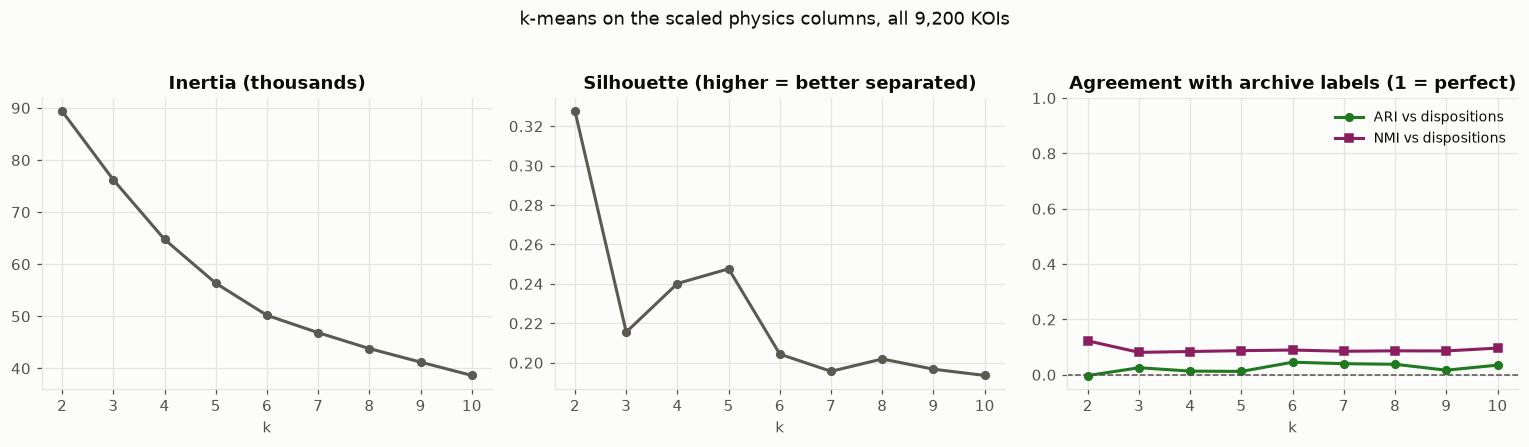

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
ks = sweep.index
axes[0].plot(ks, sweep["inertia"] / 1000, marker="o", color=viz.NEUTRAL)
axes[0].set_title("Inertia (thousands)"); axes[0].set_xlabel("k")
axes[1].plot(ks, sweep["silhouette"], marker="o", color=viz.NEUTRAL)
axes[1].set_title("Silhouette (higher = better separated)"); axes[1].set_xlabel("k")
axes[2].plot(ks, sweep["ari"], marker="o", color=viz.CLASS_COLORS["CONFIRMED"], label="ARI vs dispositions")
axes[2].plot(ks, sweep["nmi"], marker="s", color=viz.CLASS_COLORS["FALSE POSITIVE"], label="NMI vs dispositions")
axes[2].axhline(0, color=viz.TEXT_SECONDARY, lw=1, ls="--")
axes[2].set_ylim(-0.05, 1.0); axes[2].set_title("Agreement with archive labels (1 = perfect)"); axes[2].set_xlabel("k")
axes[2].legend(loc="upper right")
for ax in axes:
    ax.set_xticks(list(ks))
fig.suptitle("k-means on the scaled physics columns, all 9,200 KOIs", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "kmeans_sweep.png")
plt.show()

> **Reading the figure.** Silhouette prefers **k = 2** and falls from there; inertia has no elbow. Whatever k you choose, agreement with the dispositions stays near zero (ARI ≤ 0.05, NMI ≤ 0.13). The clusters are not planets-vs-not-planets.

## 3. What the best split actually is

For k = 2 (the silhouette choice) and k = 4 (the 2020 headline number): the cluster-by-class table, and the centroid of each cluster in standardised units. Both tables tell the same story: each cluster has the same class mix as the whole catalogue.

In [5]:
tables = {}
for k in (2, 4):
    km = clustering.fit_kmeans(X, k)
    ct = pd.crosstab(pd.Series(km.labels_, index=X.index, name=f"cluster (k={k})"), labels)
    ct["share of rows"] = ct.sum(axis=1) / len(X)
    tables[k] = (km, ct)
    display(ct.style.format({"share of rows": "{:.1%}"}).set_caption(f"k = {k}: ARI {sweep.loc[k, 'ari']:.3f}, NMI {sweep.loc[k, 'nmi']:.3f}"))

koi_disposition,CANDIDATE,CONFIRMED,FALSE POSITIVE,share of rows
cluster (k=2),,,,
0,159,106,1971,24.3%
1,2026,2186,2752,75.7%


koi_disposition,CANDIDATE,CONFIRMED,FALSE POSITIVE,share of rows
cluster (k=4),,,,
0,1124,1259,1638,43.7%
1,907,924,1214,33.1%
2,79,17,344,4.8%
3,75,92,1527,18.4%


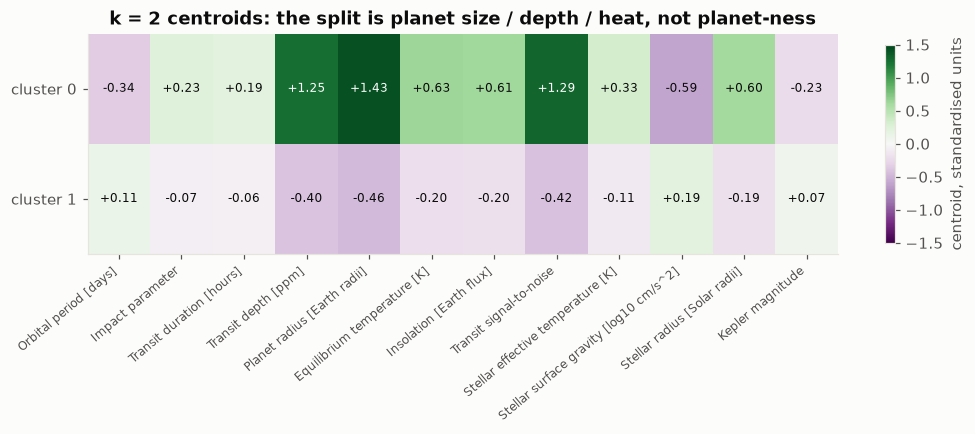

In [6]:
km2, _ = tables[2]
centroids = pd.DataFrame(km2.cluster_centers_, columns=[label(c) for c in X.columns], index=["cluster 0", "cluster 1"])
fig, ax = viz.new_figure(11, 2.6)
im = ax.imshow(centroids.to_numpy(), cmap="PRGn", vmin=-1.5, vmax=1.5, aspect="auto")
ax.set_xticks(range(centroids.shape[1])); ax.set_xticklabels(centroids.columns, rotation=40, ha="right", fontsize=8)
ax.set_yticks(range(2)); ax.set_yticklabels(centroids.index)
for i in range(2):
    for j in range(centroids.shape[1]):
        v = centroids.iloc[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.9 else viz.TEXT_PRIMARY)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.9, label="centroid, standardised units")
ax.set_title("k = 2 centroids: the split is planet size / depth / heat, not planet-ness")
fig.savefig(FIG_DIR / "centroids_k2.png")
plt.show()

## 4. The picture

Two principal components of the scaled physics columns (they carry about half the variance; the scree table shows the rest). Points are coloured by archive disposition; the numbered circles are the k = 2 and k = 4 centroids. Planets form one dense core and false positives spread around and beyond it, which is the structure the supervised models exploit. The k-means centroids do not follow that boundary: they slice the cloud along size and depth, cutting through all three classes.

In [7]:
coords, pca = clustering.pca_map(X, n_components=12)
pd.DataFrame({"explained variance": pca.explained_variance_ratio_, "cumulative": pca.explained_variance_ratio_.cumsum()},
             index=[f"PC{i + 1}" for i in range(12)]).round(3).T

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
explained variance,0.302,0.219,0.180,0.094,0.083,0.052,0.04,0.012,0.011,0.005,0.001,0.001
cumulative,0.302,0.521,0.701,0.795,0.878,0.930,0.97,0.982,0.994,0.998,0.999,1.000


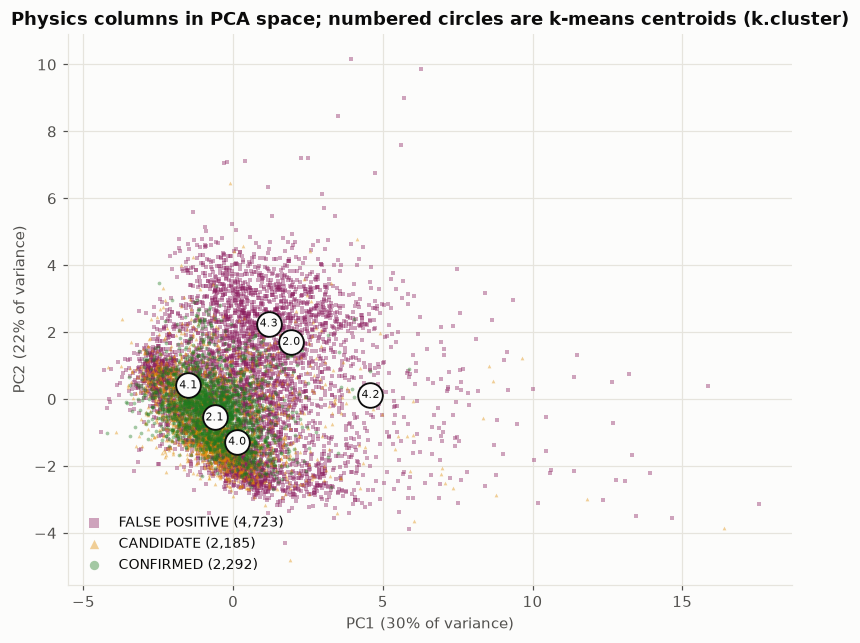

In [8]:
fig, ax = viz.new_figure(8.5, 6.5)
for cls in viz.CLASS_ORDER[::-1]:
    m = labels == cls
    ax.scatter(coords.loc[m, "PC1"], coords.loc[m, "PC2"], s=6, alpha=0.4, marker=viz.CLASS_MARKERS[cls],
               color=viz.class_color(cls), label=f"{cls} ({m.sum():,})", linewidths=0)
for k, (km, _) in tables.items():
    cent = pca.transform(pd.DataFrame(km.cluster_centers_, columns=X.columns))[:, :2]
    for i, (x, y) in enumerate(cent):
        ax.scatter(x, y, s=260, marker="o", facecolor=viz.SURFACE, edgecolor=viz.TEXT_PRIMARY, linewidths=1.2, zorder=5)
        ax.text(x, y, f"{k}.{i}", ha="center", va="center", fontsize=7.5, zorder=6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title("Physics columns in PCA space; numbered circles are k-means centroids (k.cluster)")
ax.legend(markerscale=2.5, loc="lower left")
fig.savefig(FIG_DIR / "pca_map.png")
plt.show()

## Summary — a null result, stated

- On properly scaled physics columns with every class present, k-means finds at best a weak two-way split (silhouette 0.33) that separates big/deep/hot signals from small/shallow/cool ones. The real structure in the data is a dense planet core with false positives spread around it, a gradient rather than groups.
- That split, and every other k, is **unrelated to the dispositions**: ARI ≤ 0.05, NMI ≤ 0.13, and each cluster carries the catalogue's overall class mix.
- The 2020 "elbow at 4" and the 3D cluster plot were artifacts of clustering unscaled transit depth on the planet-like half of the data.
- Answer to the 2020 question: **no**, unsupervised grouping does not reveal planet-ness; the supervised models (notebook 03) are the right tool, and their physics-only ceiling (macro f1 ≈ 0.72) is the real difficulty of the problem.